Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [7]:
import os
import random
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

In [10]:
random.seed(1234)

np.random.seed(1234)
tf.random.set_seed(1234)

In [ ]:
# 3. Conectar Google Drive y crear carpeta persistente
from google.colab import drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/PretrainedModels"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
print(f"Model directory available at: {save_dir}")

Mounted at /content/drive
Model directory available at: /content/drive/MyDrive/PretrainedModels


In [29]:
print("Available GPUs: ", tf.config.list_physical_devices('GPU'))

Available GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
# Download dataset
raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

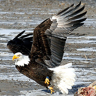
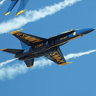
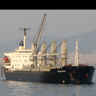
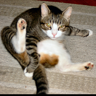

In [16]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

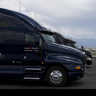
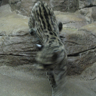
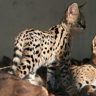
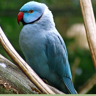

In [17]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [18]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32)

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [19]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [20]:
BATCH_SIZE = 32 

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data (if you plan to evaluate later)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Helper Functions

In [21]:
def plot_history(history, model_name="Model"):
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [22]:
def train_model(model, train_data, val_data, model_name="Model", learning_rate=0.001, epochs=25):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    )
]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    return history


# Pretrained Models

## ResNet50

In [40]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_resnet50_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape = input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    x = preprocess_input(x)
    
    base_model = ResNet50(
        weights='imagenet',
        include_top = False,
        input_shape=input_shape
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    # Add Dropout

    x = layers.Dropout(0.5)(x)

    outputs= layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model


## ResNet101V2

In [39]:
from tensorflow.keras.applications import ResNet101V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_input_v2

def build_resnet101v2_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape = input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    x = preprocess_input_v2(x)
    
    base_model = ResNet101V2(
        weights='imagenet',
        include_top = False,
        input_shape = input_shape
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    # Add Dropout

    x = layers.Dropout(0.5)(x)

    outputs= layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model


## VGG16

In [38]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_input_vgg
import tensorflow as tf

def build_vgg16_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    x = preprocess_input_vgg(x)
    
    base_model = VGG16(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )

    base_model.trainable = False

    x = base_model(x, training=False) 

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

## Xception


In [37]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_input_xception

def build_xception_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    x = preprocess_input_xception(x)

    base_model = Xception(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

## EfficientNetB0

In [36]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_eff

def build_efficientnetb0_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    x = preprocess_input_eff(x)
    
    base_model = EfficientNetB0(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )
    
    base_model.trainable = False 
    
    x = base_model(x, training=False)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model, base_model

In [41]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes


[ResNet50] FEATURE EXTRACTION | Learning Rate: 0.001
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.5530 - loss: 2.1169 - val_accuracy: 0.8720 - val_loss: 0.4883 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7423 - loss: 1.0876 - val_accuracy: 0.8970 - val_loss: 0.3945 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7588 - loss: 1.0148 - val_accuracy: 0.8940 - val_loss: 0.4353 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7782 - loss: 0.8764 - val_accuracy: 0.8960 - val_loss: 0.4182 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7887 - loss: 0.8386 - val_accuracy: 0.8930 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8129 - loss: 0.7544
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━

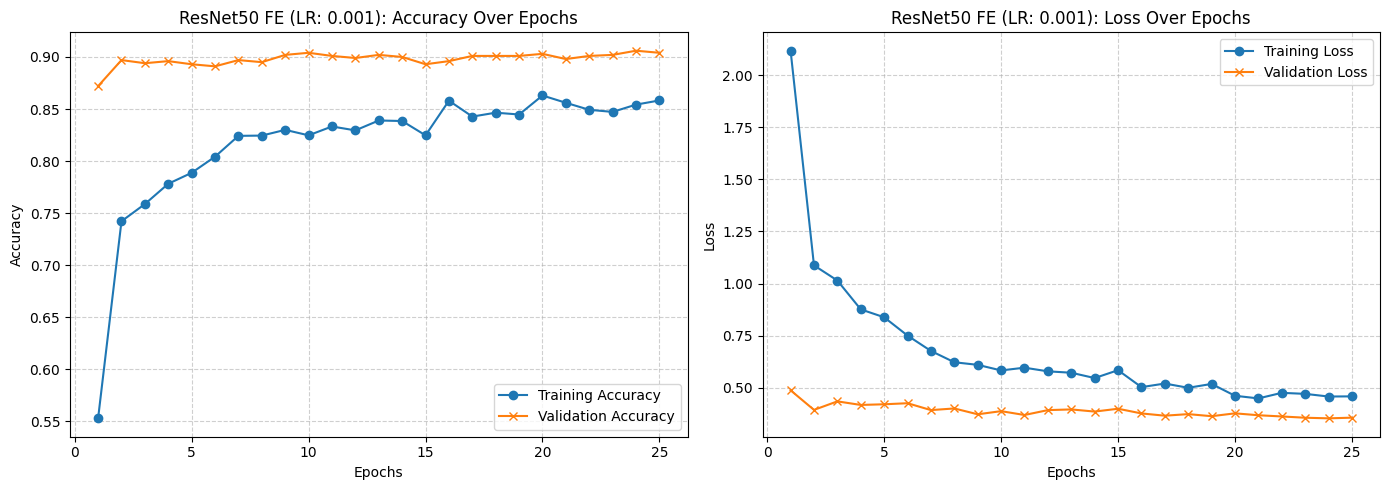


[ResNet50] FEATURE EXTRACTION | Learning Rate: 0.0005
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.4762 - loss: 2.3810 - val_accuracy: 0.8280 - val_loss: 0.5264 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6830 - loss: 1.3058 - val_accuracy: 0.8710 - val_loss: 0.4446 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7335 - loss: 1.1126 - val_accuracy: 0.8720 - val_loss: 0.4128 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7602 - loss: 0.9502 - val_accuracy: 0.8990 - val_loss: 0.3459 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7782 - loss: 0.8629 - val_accuracy: 0.8940 - val_loss: 0.3507 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7915 - loss: 0.8148 - val_accuracy: 0.8970 - val_loss: 0.3863 - learning_rate: 5.0000e-04
E

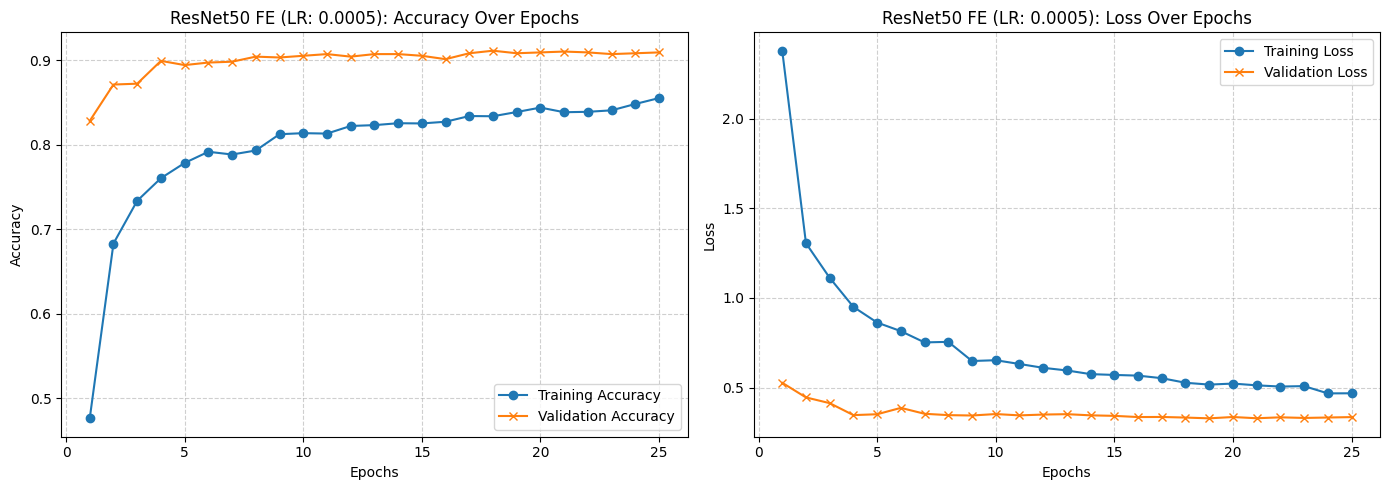


[ResNet101V2] FEATURE EXTRACTION | Learning Rate: 0.001
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.4893 - loss: 2.4595 - val_accuracy: 0.7970 - val_loss: 0.7172 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.6655 - loss: 1.4510 - val_accuracy: 0.8140 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.7067 - loss: 1.2235 - val_accuracy: 0.8290 - val_loss: 0.6594 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.7247 - loss: 1.1493 - val_accuracy: 0.8410 - val_loss: 0.6104 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.7230 - loss: 1.0556 - val_accuracy: 0.8320 - val_loss: 0.5758 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.7377 - loss: 0.9802 - val_accuracy: 0.8420 - val_loss: 0.5518 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━

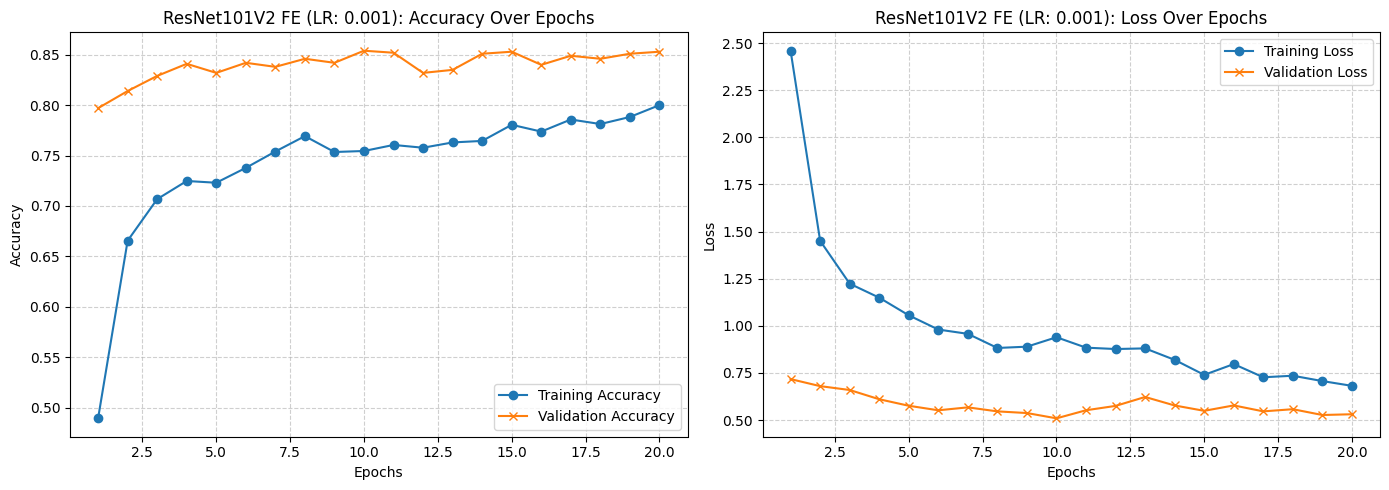


[ResNet101V2] FEATURE EXTRACTION | Learning Rate: 0.0005
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.3920 - loss: 3.1218 - val_accuracy: 0.7570 - val_loss: 0.8993 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.5978 - loss: 1.7023 - val_accuracy: 0.7910 - val_loss: 0.7455 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.6705 - loss: 1.3851 - val_accuracy: 0.8260 - val_loss: 0.6227 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.6892 - loss: 1.2165 - val_accuracy: 0.8340 - val_loss: 0.5974 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.7155 - loss: 1.1122 - val_accuracy: 0.8340 - val_loss: 0.5881 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.7140 - loss: 1.0784 - val_accuracy: 0.8420 - val_loss: 0.5729 - learning_rate: 5.0000e-0

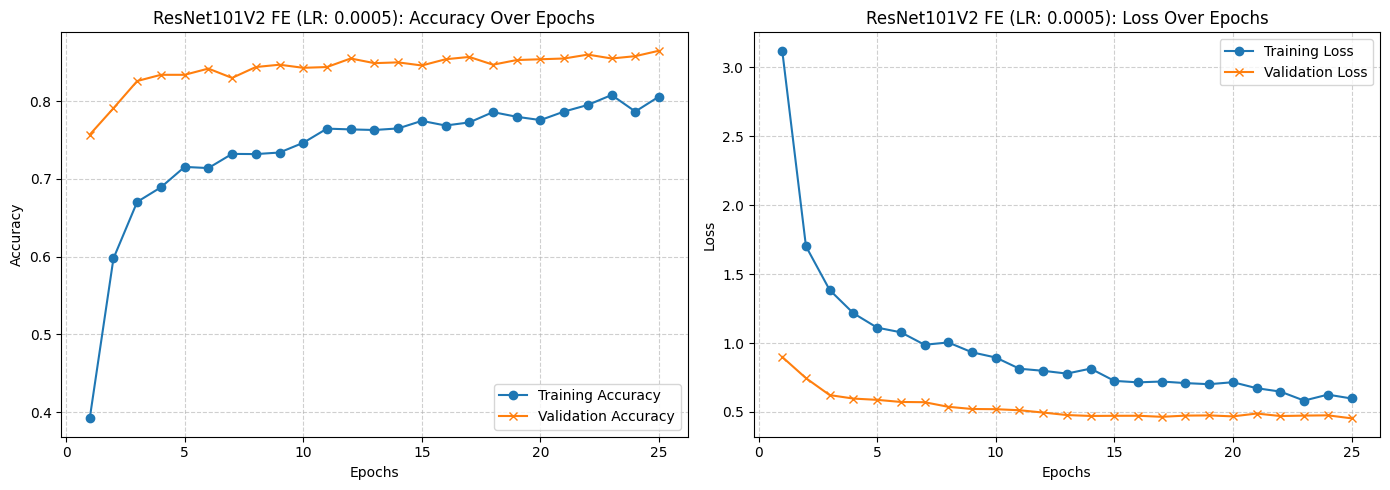


[VGG16] FEATURE EXTRACTION | Learning Rate: 0.001
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.3010 - loss: 11.2215 - val_accuracy: 0.6990 - val_loss: 2.8635 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5347 - loss: 5.2300 - val_accuracy: 0.8030 - val_loss: 1.7655 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6127 - loss: 4.0594 - val_accuracy: 0.8260 - val_loss: 1.4384 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.6525 - loss: 3.1543 - val_accuracy: 0.8630 - val_loss: 1.1160 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6873 - loss: 2.6461 - val_accuracy: 0.8600 - val_loss: 1.0286 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.6827 - loss: 2.3557 - val_accuracy: 0.8650 - val_loss: 0.9480 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━

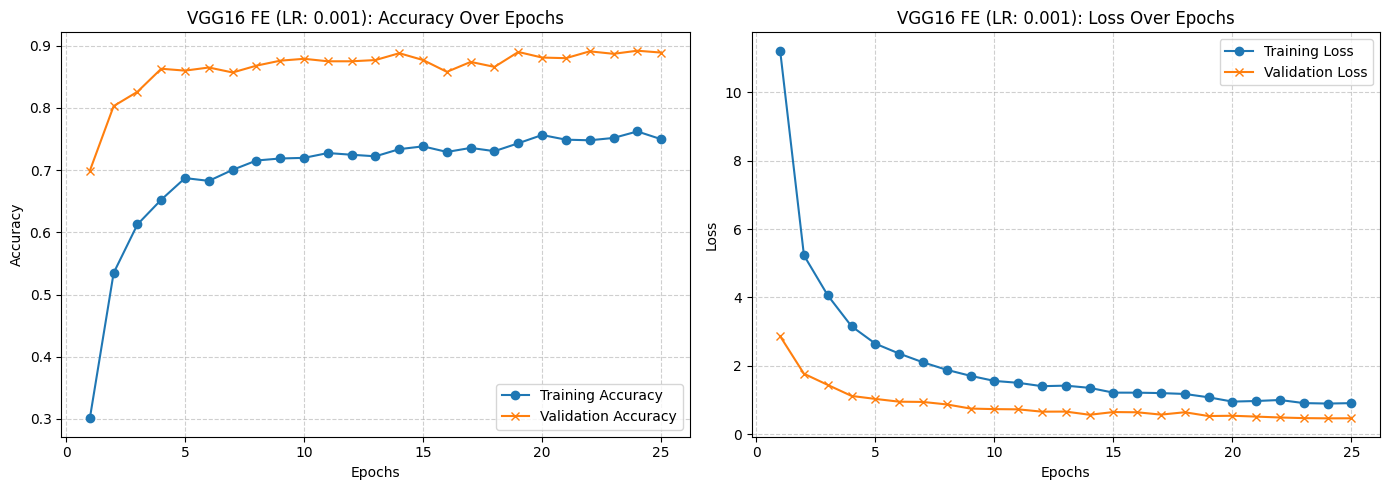


[VGG16] FEATURE EXTRACTION | Learning Rate: 0.0005
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.1988 - loss: 15.4735 - val_accuracy: 0.4660 - val_loss: 5.5475 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.3828 - loss: 8.6049 - val_accuracy: 0.6730 - val_loss: 2.8996 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.4815 - loss: 6.1299 - val_accuracy: 0.7590 - val_loss: 2.0670 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5587 - loss: 4.9231 - val_accuracy: 0.7960 - val_loss: 1.6731 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5940 - loss: 4.0629 - val_accuracy: 0.8140 - val_loss: 1.4328 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6285 - loss: 3.6446 - val_accuracy: 0.8400 - val_loss: 1.2268 - learning_rate: 5.0000e-04
Epoch

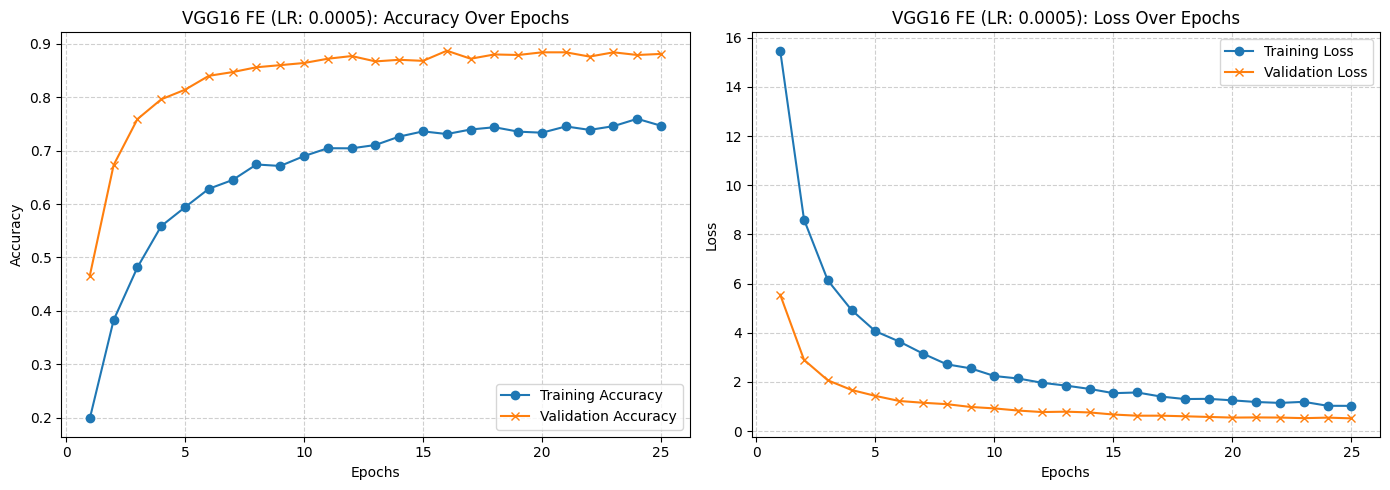


[Xception] FEATURE EXTRACTION | Learning Rate: 0.001
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.5625 - loss: 1.3038 - val_accuracy: 0.8370 - val_loss: 0.5350 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7070 - loss: 0.8660 - val_accuracy: 0.8510 - val_loss: 0.4607 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7372 - loss: 0.7776 - val_accuracy: 0.8740 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7375 - loss: 0.7646 - val_accuracy: 0.8670 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7690 - loss: 0.7021 - val_accuracy: 0.8700 - val_loss: 0.4277 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7688 - loss: 0.7198 - val_accuracy: 0.8630 - val_loss: 0.4405 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━

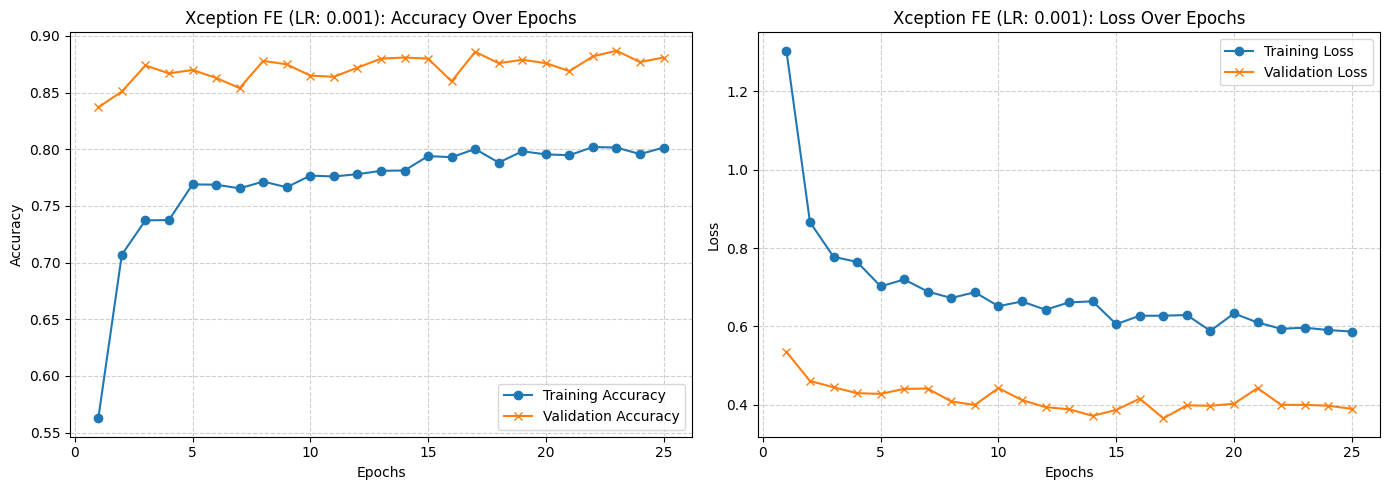


[Xception] FEATURE EXTRACTION | Learning Rate: 0.0005
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.4703 - loss: 1.5542 - val_accuracy: 0.8130 - val_loss: 0.6083 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6783 - loss: 0.9554 - val_accuracy: 0.8460 - val_loss: 0.5078 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7195 - loss: 0.8468 - val_accuracy: 0.8570 - val_loss: 0.4770 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7230 - loss: 0.8034 - val_accuracy: 0.8660 - val_loss: 0.4417 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7293 - loss: 0.7778 - val_accuracy: 0.8740 - val_loss: 0.4309 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7580 - loss: 0.7256 - val_accuracy: 0.8750 - val_loss: 0.4137 - learning_rate: 5.0000e-04
Ep

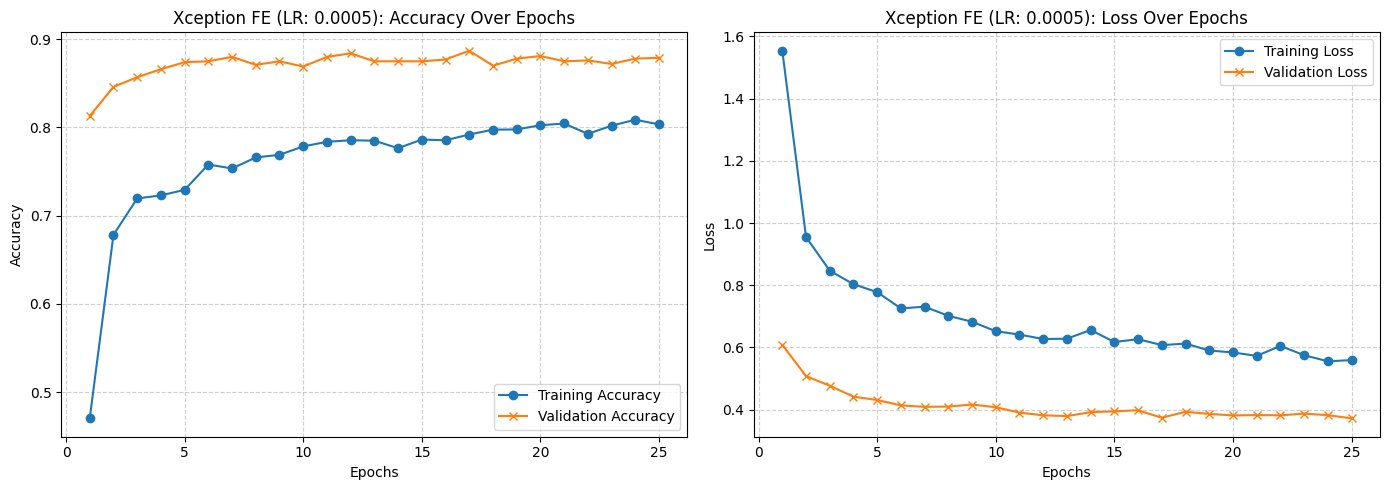


[EfficientNet] FEATURE EXTRACTION | Learning Rate: 0.001
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.5660 - loss: 1.3708 - val_accuracy: 0.8710 - val_loss: 0.5887 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7857 - loss: 0.7084 - val_accuracy: 0.9040 - val_loss: 0.3958 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8070 - loss: 0.6041 - val_accuracy: 0.9130 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8295 - loss: 0.5507 - val_accuracy: 0.9200 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8342 - loss: 0.5189 - val_accuracy: 0.9130 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8372 - loss: 0.4877 - val_accuracy: 0.9220 - val_loss: 0.2798 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━

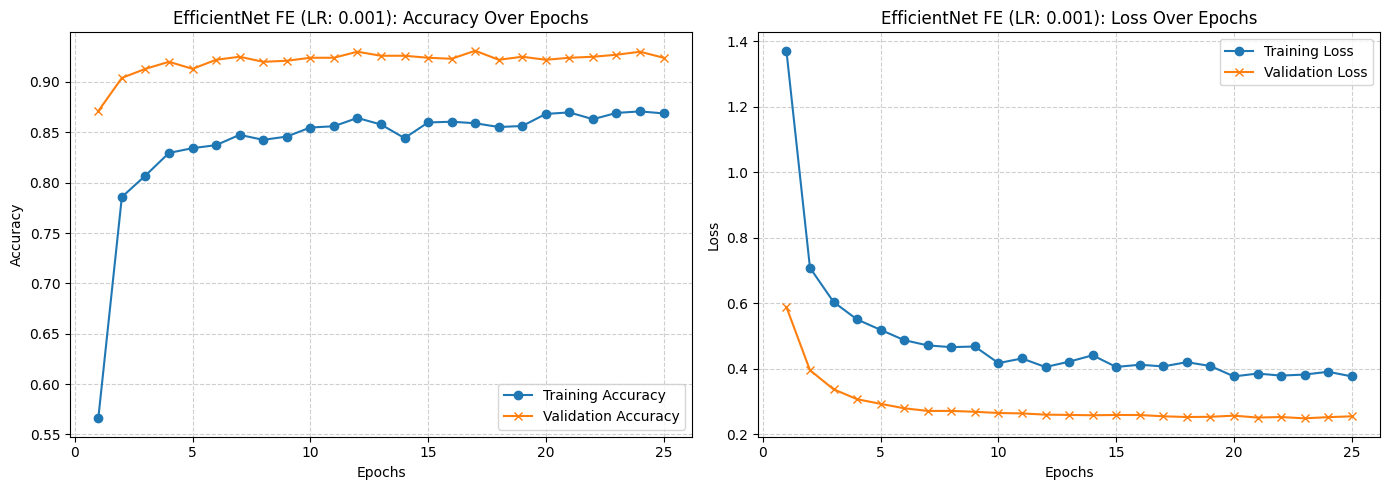


[EfficientNet] FEATURE EXTRACTION | Learning Rate: 0.0005
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.4250 - loss: 1.7372 - val_accuracy: 0.8140 - val_loss: 0.9915 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7182 - loss: 0.9837 - val_accuracy: 0.8790 - val_loss: 0.6248 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7623 - loss: 0.7844 - val_accuracy: 0.8890 - val_loss: 0.4902 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7933 - loss: 0.6662 - val_accuracy: 0.9010 - val_loss: 0.4186 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7985 - loss: 0.6228 - val_accuracy: 0.9070 - val_loss: 0.3776 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8108 - loss: 0.5897 - val_accuracy: 0.9130 - val_loss: 0.3534 - learning_rate: 5.0000e-0

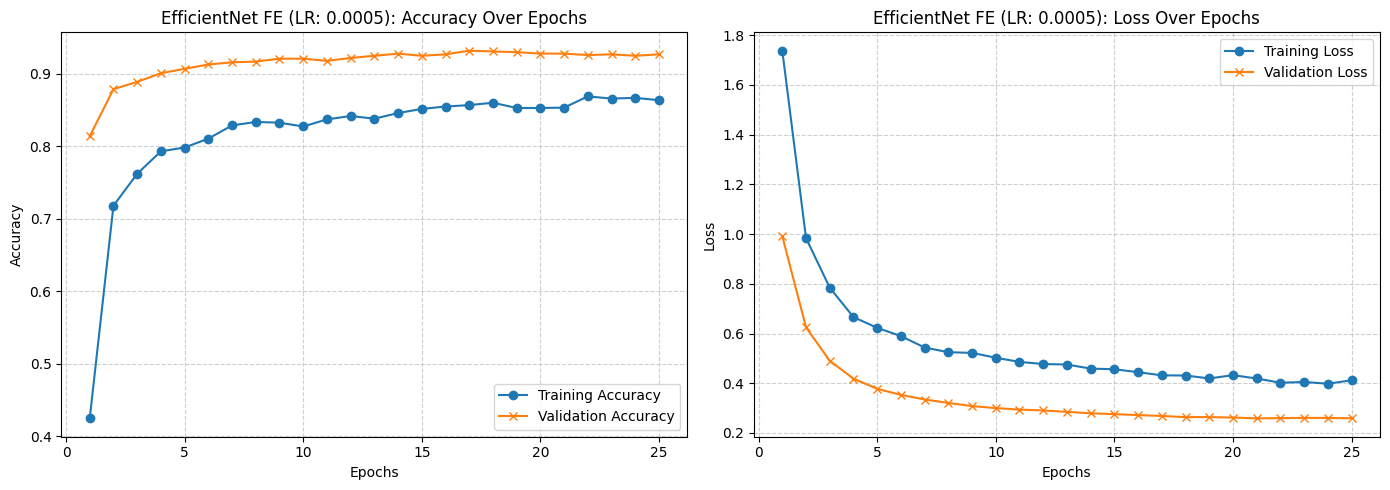

In [42]:
models_to_test = {
    "ResNet50": build_resnet50_model,
    "ResNet101V2": build_resnet101v2_model,
    "VGG16": build_vgg16_model,
    "Xception": build_xception_model,
    "EfficientNet": build_efficientnetb0_model
}

learning_rates = [0.001, 0.0005]
dropout_rate = 0.3

for model_name, build_func in models_to_test.items():
    for lr in learning_rates:
        print(f"\n{'='*60}")
        print(f"[{model_name}] FEATURE EXTRACTION | Learning Rate: {lr}")
        print(f"{'='*60}")
        
        model, base_model = build_func(img_shape, num_classes)
        
        history = train_model(model, train_data, val_data, learning_rate=lr, epochs=25)
        
        # Encontrar mejores métricas
        best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
        best_val_acc = history.history['val_accuracy'][best_epoch]
        
        # Guardar Modelo
        model_filename = f"{save_dir}/{model_name}_FE_lr_{lr}.keras"
        model.save(model_filename)
        print(f"Modelo guardado en: {model_filename}")
        
        # Dibujar gráficas
        plot_history(history, model_name=f"{model_name} FE (LR: {lr})")
        
        # Guardar Hiperparámetros en JSON
        hyperparams = {
            'model_architecture': model_name,
            'learning_rate': lr,
            'dropout_rate': dropout_rate,
            'phase': 'Feature_Extraction',
            'best_val_accuracy': best_val_acc
        }
        json_path = os.path.join(save_dir, f"{model_name}_FE_lr_{lr}_hyperparams.json")
        with open(json_path, 'w') as json_file:
            json.dump(hyperparams, json_file, indent=4)

# Fine-Tuning


STARTING FINE-TUNING: ResNet50
Best FE model found using LR: 0.0005 (Validation Accuracy: 0.9080)
Base model unfrozen. Total layers: 175. Training the last 35.
Starting training with LR Fine-Tuning: 1e-05
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.7730 - loss: 0.6587 - val_accuracy: 0.9010 - val_loss: 0.3200 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.7890 - loss: 0.6125 - val_accuracy: 0.8970 - val_loss: 0.3127 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.8043 - loss: 0.5457 - val_accuracy: 0.9000 - val_loss: 0.3119 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8305 - loss: 0.4871 - val_accuracy: 0.9100 - val_loss: 0.3011 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8353 - loss: 0.4610 - val_accuracy: 0.9110 - val_loss: 0.2859 - learning_rate: 1.0000e-05
Epoch 

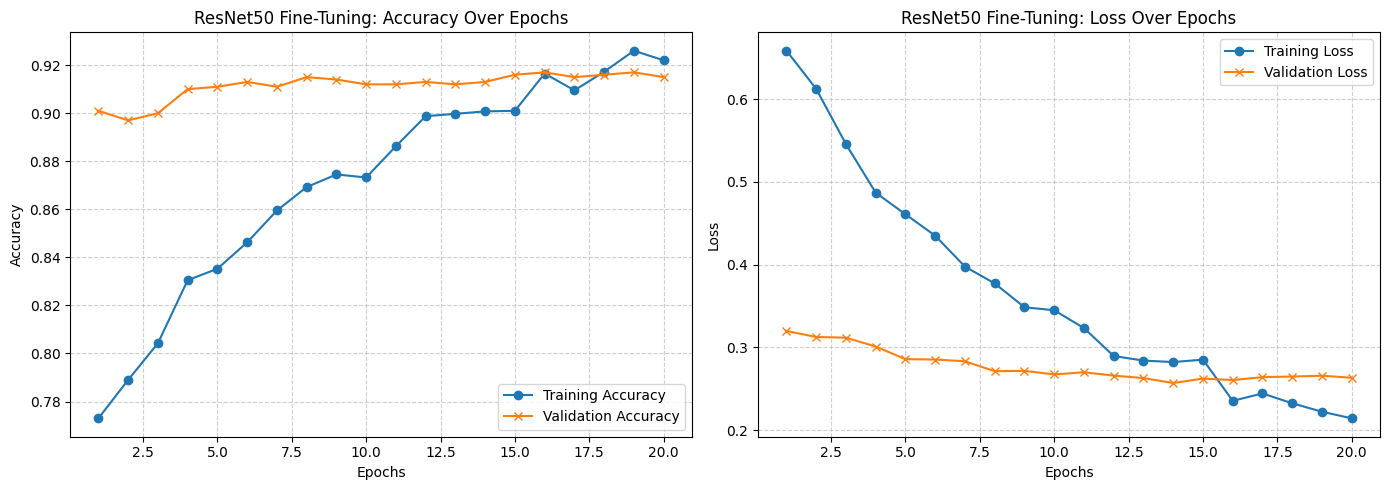


STARTING FINE-TUNING: ResNet101V2
Best FE model found using LR: 0.0005 (Validation Accuracy: 0.8650)
Base model unfrozen. Total layers: 377. Training the last 76.
Starting training with LR Fine-Tuning: 1e-05
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 149ms/step - accuracy: 0.5675 - loss: 1.2357 - val_accuracy: 0.8300 - val_loss: 0.5243 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.6258 - loss: 1.0618 - val_accuracy: 0.8030 - val_loss: 0.5733 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.6855 - loss: 0.9230 - val_accuracy: 0.8150 - val_loss: 0.5492 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.7097 - loss: 0.8288 - val_accuracy: 0.8190 - val_loss: 0.5141 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.7372 - loss: 0.7708 - val_accuracy: 0.8280 - val_loss: 0.4897 - learning_rate: 1.0000e

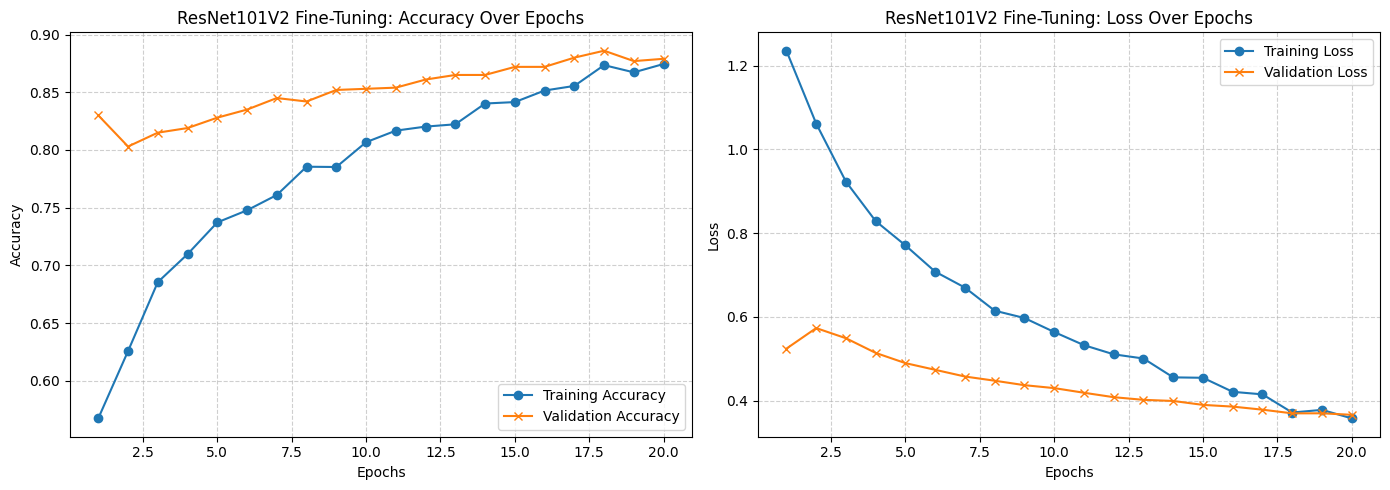


STARTING FINE-TUNING: VGG16
Best FE model found using LR: 0.001 (Validation Accuracy: 0.8920)
Base model unfrozen. Total layers: 19. Training the last 4.
Starting training with LR Fine-Tuning: 1e-05
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7602 - loss: 0.7576 - val_accuracy: 0.8910 - val_loss: 0.3886 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7800 - loss: 0.6093 - val_accuracy: 0.8950 - val_loss: 0.3473 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.7928 - loss: 0.5843 - val_accuracy: 0.8980 - val_loss: 0.3463 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8288 - loss: 0.4998 - val_accuracy: 0.8940 - val_loss: 0.3454 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8292 - loss: 0.4808 - val_accuracy: 0.8930 - val_loss: 0.3483 - learning_rate: 1.0000e-05
Epoch 6/20
125

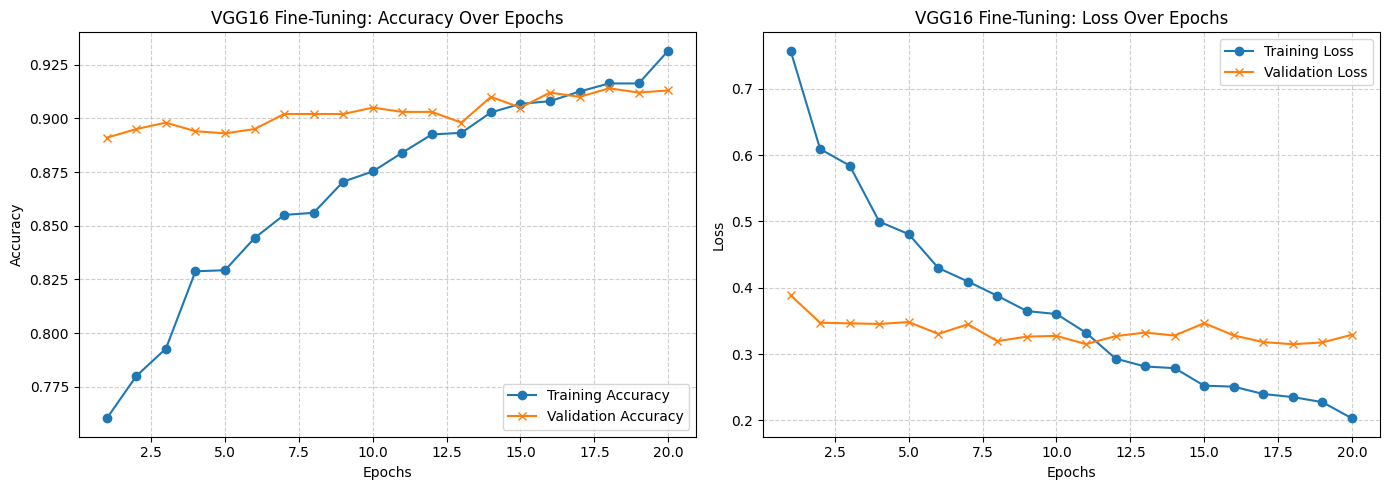


STARTING FINE-TUNING: Xception
Best FE model found using LR: 0.001 (Validation Accuracy: 0.8860)
Base model unfrozen. Total layers: 132. Training the last 27.
Starting training with LR Fine-Tuning: 1e-05
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.5840 - loss: 1.4183 - val_accuracy: 0.8690 - val_loss: 0.4363 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.6852 - loss: 1.1846 - val_accuracy: 0.8650 - val_loss: 0.4559 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.7220 - loss: 0.9976 - val_accuracy: 0.8550 - val_loss: 0.5367 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.7460 - loss: 0.9050 - val_accuracy: 0.8580 - val_loss: 0.5519 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7514 - loss: 0.8333
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
125

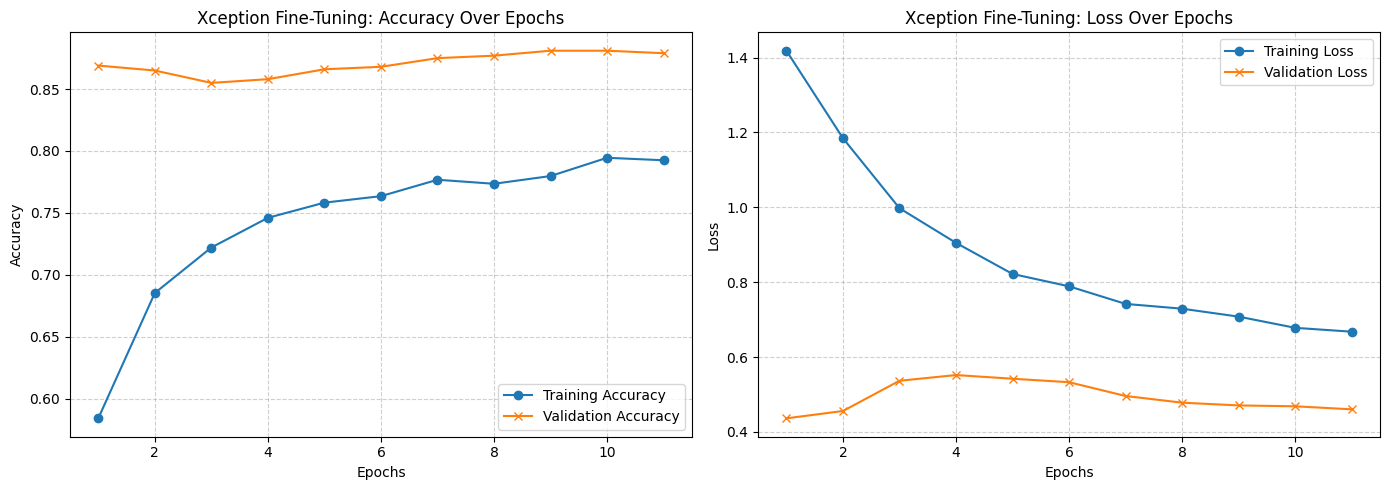


STARTING FINE-TUNING: EfficientNet
Best FE model found using LR: 0.0005 (Validation Accuracy: 0.9280)
Base model unfrozen. Total layers: 238. Training the last 48.
Starting training with LR Fine-Tuning: 1e-05
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.7355 - loss: 0.8138 - val_accuracy: 0.8960 - val_loss: 0.3457 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7410 - loss: 0.7579 - val_accuracy: 0.8830 - val_loss: 0.3922 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7673 - loss: 0.7003 - val_accuracy: 0.8800 - val_loss: 0.3977 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7740 - loss: 0.6599 - val_accuracy: 0.8820 - val_loss: 0.3878 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7772 - loss: 0.6554
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06

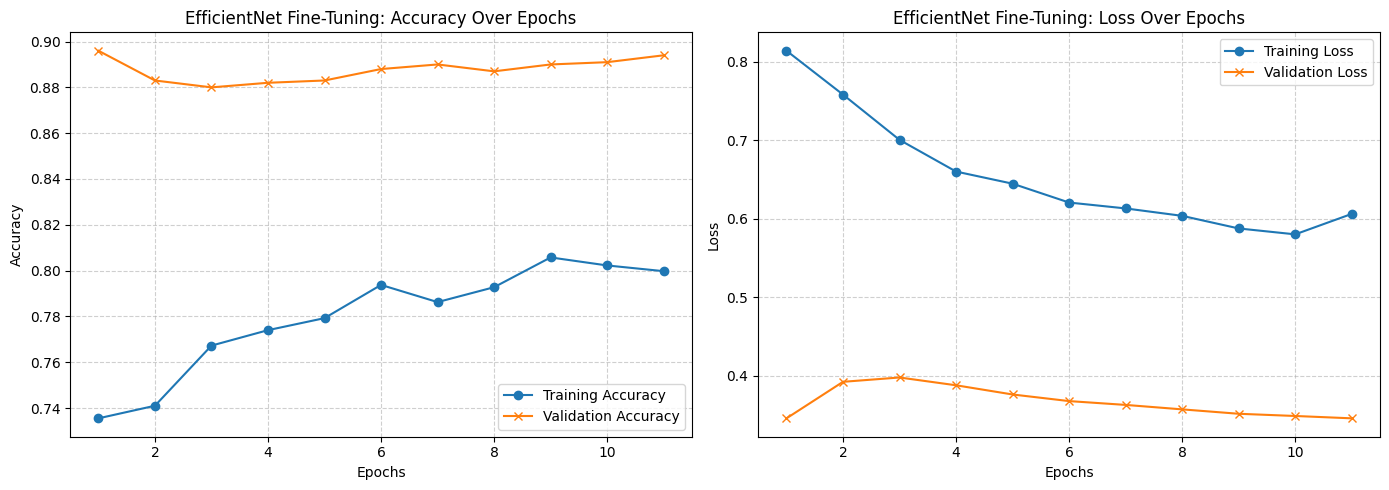

In [43]:
model_names = ["ResNet50", "ResNet101V2", "VGG16", "Xception", "EfficientNet"]
learning_rates_used = [0.001, 0.0005] 

for model_name in model_names:
    print(f"\n{'='*70}")
    print(f"STARTING FINE-TUNING: {model_name}")
    print(f"{'='*70}")
    
    # 1. Buscar el mejor modelo de Feature Extraction leyendo los JSONs guardados
    best_lr = None
    best_acc = 0
    
    for lr in learning_rates_used:
        json_path = os.path.join(save_dir, f"{model_name}_FE_lr_{lr}_hyperparams.json")
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                data = json.load(f)
                if data['best_val_accuracy'] > best_acc:
                    best_acc = data['best_val_accuracy']
                    best_lr = lr
                    
    if best_lr is None:
        print(f"No feature extraction files were found for {model_name}. Skipping...")
        continue
        
    print(f"Best FE model found using LR: {best_lr} (Validation Accuracy: {best_acc:.4f})")
    
    # 2. Cargar el modelo .keras correspondiente
    model_path = os.path.join(save_dir, f"{model_name}_FE_lr_{best_lr}.keras")
    model = tf.keras.models.load_model(model_path)
    
    # 3. Identificar y descongelar el modelo base
    base_model = None
    for layer in model.layers:
        # Detectamos cuál de las capas es el modelo preentrenado (VGG, ResNet...)
        if isinstance(layer, tf.keras.Model): 
            base_model = layer
            break
            
    if base_model:
        base_model.trainable = True
        
        # Estrategia de Fine-Tuning: Congelar el 80% inicial y descongelar el 20% final.
        # Esto es vital porque VGG tiene 19 capas pero ResNet tiene más de 150.
        num_layers = len(base_model.layers)
        frozen_layers = int(num_layers * 0.8) 
        
        for layer in base_model.layers[:frozen_layers]:
            layer.trainable = False
            
        print(f"Base model unfrozen. Total layers: {num_layers}. Training the last {num_layers - frozen_layers}.")
    else:
        print("No internal base model was detected. Everything will be fine-tuned.")
        
    # 4. Recompilar y entrenar con un Learning Rate MUY bajo
    ft_lr = 1e-5
    print(f"Starting training with LR Fine-Tuning: {ft_lr}")
    
    # Usamos tu función de entrenamiento (que internamente hace el model.compile)
    history_ft = train_model(
        model=model, 
        train_data=train_data, 
        val_data=val_data, 
        learning_rate=ft_lr, 
        epochs=20 # En Fine-tuning suele haber overfitting antes, 20 está bien
    )
    
    # 5. Identificar mejores métricas y guardar
    best_epoch_ft = history_ft.history['val_loss'].index(min(history_ft.history['val_loss']))
    best_val_acc_ft = history_ft.history['val_accuracy'][best_epoch_ft]
    
    ft_model_path = os.path.join(save_dir, f"{model_name}_FT.keras")
    model.save(ft_model_path)
    print(f"Fine-tuned model saved in: {ft_model_path}")
    
    # 6. Guardar Hiperparámetros de esta fase
    hyperparams_ft = {
        'model_architecture': model_name,
        'best_feature_extraction_lr': best_lr,
        'fine_tuning_lr': ft_lr,
        'phase': 'Fine_Tuning',
        'best_val_accuracy': best_val_acc_ft
    }
    
    json_path_ft = os.path.join(save_dir, f"{model_name}_FT_hyperparams.json")
    with open(json_path_ft, 'w') as json_file:
        json.dump(hyperparams_ft, json_file, indent=4)
        
    # 7. Imprimir gráficas
    plot_history(history_ft, model_name=f"{model_name} Fine-Tuning")

In [44]:
print("\n" + "=" * 60)
print("FINAL EVALUATION IN TEST SET")
print("=" * 60)

model_names = ["ResNet50", "ResNet101V2", "VGG16", "Xception", "EfficientNet"]
learning_rates_usados = [0.001, 0.0005]

# ---------------------------------------------------------
# 1. Evaluación de los modelos de Feature Extraction
# ---------------------------------------------------------
print("\n--- Results Feature Extraction ---")
for model_name in model_names:
    # Buscar cuál fue el mejor LR para este modelo
    best_lr = None
    best_acc = 0
    for lr in learning_rates_usados:
        json_path = os.path.join(save_dir, f"{model_name}_FE_lr_{lr}_hyperparams.json")
        if os.path.exists(json_path):
            import json
            with open(json_path, 'r') as f:
                data = json.load(f)
                if data['best_val_accuracy'] > best_acc:
                    best_acc = data['best_val_accuracy']
                    best_lr = lr
                    
    if best_lr is not None:
        fe_model_path = os.path.join(save_dir, f"{model_name}_FE_lr_{best_lr}.keras")
        if os.path.exists(fe_model_path):
            model_fe = tf.keras.models.load_model(fe_model_path)
            loss, acc = model_fe.evaluate(test_data, verbose=0)
            print(f"- {model_name:<15} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")
    else:
        print(f"- {model_name:<15} -> [Model not found]")

# ---------------------------------------------------------
# 2. Evaluación de los modelos de Fine-Tuning
# ---------------------------------------------------------
print("\n--- Results Fine-Tuning ---")
for model_name in model_names:
    ft_model_path = os.path.join(save_dir, f"{model_name}_FT.keras")
    
    if os.path.exists(ft_model_path):
        model_ft = tf.keras.models.load_model(ft_model_path)
        loss, acc = model_ft.evaluate(test_data, verbose=0)
        print(f"- {model_name:<15} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")
    else:
        print(f"- {model_name:<15} -> [Model not found]")

print("\n" + "=" * 60)


FINAL EVALUATION IN TEST SET

--- Results Feature Extraction ---
- ResNet50        -> Accuracy: 0.8951 | Loss: 0.3407
- ResNet101V2     -> Accuracy: 0.8591 | Loss: 0.4869
- VGG16           -> Accuracy: 0.8643 | Loss: 0.5238
- Xception        -> Accuracy: 0.8650 | Loss: 0.4209
- EfficientNet    -> Accuracy: 0.9145 | Loss: 0.2807

--- Results Fine-Tuning ---
- ResNet50        -> Accuracy: 0.9039 | Loss: 0.2838
- ResNet101V2     -> Accuracy: 0.8614 | Loss: 0.4027
- VGG16           -> Accuracy: 0.9064 | Loss: 0.3308
- Xception        -> Accuracy: 0.8374 | Loss: 0.4780
- EfficientNet    -> Accuracy: 0.8889 | Loss: 0.3715

